# 📚 Machine Learning — Student Learning Notes

This version contains detailed notes before the executable cells. Read the notes first, then run the code and observe the output. The original code and notebook flow have been preserved.

**Learning approach:** Understand the purpose → run the code → observe the output → connect it to the machine-learning workflow.

## The best way to implement any machine learning problem statement.

### 1. Get/Load the data
### 2. Understand and making ready the data (Data cleaning process)
### 3. Plot the data
### 4. Machine Learning Model Creation. ( Decide the algorithm/model)
### 5. Train the model
### 6. Predict  (test the model)
### 7. check the accuracy 


### 📘 Notes — Importing the Required Libraries

This cell imports the Python libraries used throughout the notebook.

- `import pandas as pd` → imports **Pandas**, which is mainly used for creating and working with tables/DataFrames. `pd` is the common short name.
- `import numpy as np` → imports **NumPy**, which provides numerical tools and special values such as `np.nan` for a missing value.
- `from sklearn import linear_model` → imports the Linear Regression tools from **Scikit-learn**, our machine-learning library.
- `import matplotlib.pyplot as plt` → imports Matplotlib's plotting functions. `plt` is used to create graphs.
- `import warnings` → gives Python access to warning controls.
- `warnings.filterwarnings("ignore")` → hides warning messages in the notebook. This can make a classroom notebook cleaner, but during real development it is usually better to understand and fix warnings rather than hide them.

**Student idea:** Libraries are pre-written code that save us from building everything ourselves.

In [2]:
# Import the required libraries. (if nothing is available then install them using ->>  pip install "library name" ( Ex: pip install pandas)
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### 📘 Notes — Creating / Loading the Dataset

This cell creates a small sample dataset containing **house area** and **house price**.

- `data = [...]` creates a Python list containing multiple records.
- Each record is a dictionary such as `{'area': '1000', 'price': '1500000'}`.
- `area` is the input feature we want to use to predict price.
- `price` is the target/output we want the model to learn.
- Some prices are deliberately missing (`None` or `np.nan`) so that we can learn data-cleaning techniques.
- The values are initially written as strings in several records. Later, students should notice that ML algorithms generally need numerical values for numerical features.
- `pd.DataFrame(data)` converts the list of dictionaries into a Pandas table.

**Machine-learning idea:** We first need data before we can train a model. Here, we are creating a small example instead of loading a CSV/database.

In [3]:
# Load or get/prepare the data

data = [
    {'area': '1000', 'price': '1500000'},
    {'area': '1000', 'price': None},
    {'area': '2000', 'price': '3500000'},
    {'area': '2500', 'price': np.nan },
    {'area': '3000', 'price': '5500000'},
    {'area': '4000', 'price': '6500000'},
    {'area': '5000', 'price': '7500000'},
    {'area': '6000', 'price': '7500000'},
    {'area': '7000', 'price': np.nan},
    {'area': '8000', 'price': '9500000'},
]
df = pd.DataFrame(data)



## Understad the data using pandas. 


### 📘 Notes — Display the Complete DataFrame

`df` displays the current Pandas DataFrame.

This is useful as a first look at the dataset.

Students should check:
- What columns are present?
- How many rows are there?
- Are any values missing?
- Do the values look like numbers or text?

In a Jupyter Notebook, simply writing `df` displays the DataFrame without needing `print(df)`.

In [4]:
df

,area,price
0,1000,1500000
1,1000,None
2,2000,3500000
3,2500,NaN
4,3000,5500000
5,4000,6500000
6,5000,7500000
7,6000,7500000
8,7000,NaN
9,8000,9500000


### 📘 Notes — View the First Records

`df.head(3)` displays the first **3 rows** of the DataFrame.

- `head()` is useful for quickly checking the beginning of a dataset.
- The number inside the brackets tells Pandas how many rows to show.
- If no number is supplied, `df.head()` normally shows the first 5 rows.

**Example:** `df.head(2)` → first 2 rows.

In [5]:
df.head(3)

,area,price
0,1000,1500000
1,1000,None
2,2000,3500000


### 📘 Notes — View the Last Records

`df.tail()` displays the last **5 rows** by default.

This helps us inspect the end of the dataset.

You can also specify a number:
`df.tail(3)` → displays the last 3 rows.

In [6]:
df.tail()

,area,price
5,4000,6500000
6,5000,7500000
7,6000,7500000
8,7000,NaN
9,8000,9500000


### 📘 Notes — View Random Records

`df.sample(5)` randomly selects **5 rows** from the DataFrame.

Why is this useful?
- A large dataset may contain thousands or millions of rows.
- Looking at random records can help us quickly check whether the data has a consistent structure.
- It can sometimes reveal unexpected values that we would miss by looking only at the first or last rows.

The number `5` means we want five random rows.

In [7]:
df.sample(5)

,area,price
0,1000,1500000
9,8000,9500000
2,2000,3500000
6,5000,7500000
7,6000,7500000


### 📘 Notes — Understand Data Types and Structure

`df.info()` gives a compact summary of the DataFrame.

It shows:
- Number of rows
- Column names
- Number of non-null values
- Data types (`object`, `int`, `float`, etc.)
- Approximate memory usage

This is especially important before machine learning because we need to know whether our columns contain numeric values, text, or missing data.

**Important observation for this notebook:** the `area` and `price` values were entered as strings in several records. Data types should be checked before training the model.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   area    10 non-null     object
 1   price   7 non-null      object
dtypes: object(2)
memory usage: 292.0+ bytes


### 📘 Notes — Statistical Summary

`df.describe()` generates descriptive statistics for numeric columns.

Typical values include:
- `count` → number of non-missing values
- `mean` → average
- `std` → standard deviation
- `min` → smallest value
- `25%` → first quartile
- `50%` → median
- `75%` → third quartile
- `max` → largest value

This is useful for understanding the distribution and range of numerical data.

If a column is stored as text (`object`), Pandas may not include it in the normal numeric summary. That is another reason why checking data types is important.

In [9]:
df.describe()

,area,price
count,10,7
unique,9,6
top,1000,7500000
freq,2,2


### 📘 Notes — Inspect DataFrame Information

`df.info()` helps us inspect:
- column names,
- number of entries,
- non-null counts,
- and data types.

This is an important data-cleaning step before applying a machine-learning algorithm.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   area    10 non-null     object
 1   price   7 non-null      object
dtypes: object(2)
memory usage: 292.0+ bytes


### 📘 Notes — Generate Descriptive Statistics

`df.describe()` provides statistical information for numeric columns.

Use it to understand the approximate range and distribution of your data before building a model.

In [29]:
df.describe()

,area,price
count,10,8
unique,10,7
top,1000,7500000
freq,1,2


### 📘 Notes — Find Missing Values

`df.isnull()` checks every cell and returns:
- `True` → the cell contains a missing/null value.
- `False` → the cell is not missing.

It does not remove or change anything. It only **detects** missing values.

For a total count of missing values by column, a commonly useful follow-up is:
`df.isnull().sum()`

**Student idea:** Before training a model, always check whether important input or target values are missing.

In [39]:
df.isnull()

,area,price
0,False,False
1,False,True
2,False,False
3,False,True
4,False,False
5,False,False
6,False,False
7,False,False
8,False,True
9,False,False


### 📘 Notes — Replace Missing Values with Zero

`df.fillna(0)` creates a version of the DataFrame where missing values are replaced with `0`.

- `fillna()` means "fill missing values".
- `0` is the replacement value.

**Important:** This expression does not permanently change `df` unless the result is assigned back to `df` or `inplace=True` is used.

Example:
`df = df.fillna(0)`

Also, replacing a missing house price with zero may not be logically correct for a real ML problem. The replacement strategy should depend on the meaning of the data.

In [40]:
df.fillna(0)


,area,price
0,1000,1500000
1,1000,0
2,2000,3500000
3,2500,0
4,3000,5500000
5,4000,6500000
6,5000,7500000
7,6000,7500000
8,7000,0
9,8000,9500000


### 📘 Notes — Forward Fill

`df.fillna(method='pad')` fills a missing value using the **previous available value**.

For example:

Previous value = 3,500,000  
Current value = missing  
→ Current value becomes 3,500,000

This technique is called **forward fill**.

**Important:** It is appropriate only when carrying the previous value forward makes sense for the particular dataset. It is not automatically the correct choice for house prices.

In [41]:
#The pad method is used to fill missing values with the previous value.
df.fillna(method='pad')

,area,price
0,1000,1500000
1,1000,1500000
2,2000,3500000
3,2500,3500000
4,3000,5500000
5,4000,6500000
6,5000,7500000
7,6000,7500000
8,7000,7500000
9,8000,9500000


### 📘 Notes — Backward Fill

`df.fillna(method='bfill')` fills a missing value using the **next available value**.

For example:

Current value = missing  
Next value = 5,500,000  
→ Current value becomes 5,500,000

This is called **backward fill**.

Again, whether this is appropriate depends on the meaning and ordering of the data.

In [42]:
#The bfill function is used to fill it with the next value.

df.fillna(method='bfill') 


,area,price
0,1000,1500000
1,1000,3500000
2,2000,3500000
3,2500,5500000
4,3000,5500000
5,4000,6500000
6,5000,7500000
7,6000,7500000
8,7000,9500000
9,8000,9500000


### 📘 Notes — Replace Missing Values with a Specific Value

`df.replace(to_replace=np.nan, value=100)` replaces `NaN` values with `100`.

- `df.replace()` is a general replacement function.
- `to_replace=np.nan` identifies missing numerical values represented by `NaN`.
- `value=100` specifies what should replace them.
- The result is stored in a new variable called `data`.
- `print(data)` displays the resulting DataFrame.

**Important:** The number `100` is only an example. In a real dataset, choose a replacement based on the meaning of the column. For example, mean/median imputation may sometimes be considered for numerical features, while missing target values may need to be removed.

In [13]:
# we are going to replace the all NaN value in the data frame with 10 value. 

data = df.replace(to_replace=np.nan, value= 100)
print(data)


   area    price
0  1000  1500000
1  1000      100
2  2000  3500000
3  2500      100
4  3000  5500000
5  4000  6500000
6  5000  7500000
7  6000  7500000
8  7000      100
9  8000  9500000


### 📘 Notes — Remove Rows Containing Missing Values

`df.dropna()` removes rows that contain at least one missing value.

- `dropna()` means "drop rows with missing values".
- The cleaned DataFrame is stored in `df_cleaned`.
- The original `df` is not changed by this statement.

This is often useful when a row cannot be used safely because an important value is missing.

**For this example:** rows with missing `price` are removed, leaving rows that have both area and price available for the regression model.

In [14]:
# Dropping Rows with At Least One Null Value
df_cleaned = df.dropna()


### 📘 Notes — Remove Duplicate Rows

`df_cleaned.drop_duplicates()` removes duplicate rows from the cleaned DataFrame.

- Duplicate records can cause the same observation to appear more than once.
- The result is assigned back to `df_cleaned`.
- `print(df_cleaned)` then displays the cleaned data.

**Student idea:** Data cleaning means making the dataset more reliable before giving it to a machine-learning algorithm.

In [15]:
# remove duplicate rows from a DataFrame
df_cleaned = df_cleaned.drop_duplicates()
print(df_cleaned)

   area    price
0  1000  1500000
2  2000  3500000
4  3000  5500000
5  4000  6500000
6  5000  7500000
7  6000  7500000
9  8000  9500000


### 📘 Notes — Display the Final Cleaned Data

`print(df_cleaned)` prints the DataFrame after the missing-value and duplicate-removal steps.

At this stage, students should inspect the table and confirm that the rows intended for model training are available.

This is a good habit: **after cleaning data, inspect the result before training the model.**

In [16]:
print(df_cleaned)

   area    price
0  1000  1500000
2  2000  3500000
4  3000  5500000
5  4000  6500000
6  5000  7500000
7  6000  7500000
9  8000  9500000


### 📘 Notes — Visualize Area vs Price

This cell creates a scatter plot to visually inspect the relationship between house area and price.

- `%matplotlib inline` tells Jupyter to display Matplotlib plots inside the notebook.
- `plt.xlabel('area')` labels the horizontal/X axis.
- `plt.ylabel('price')` labels the vertical/Y axis.
- `plt.scatter(...)` creates a scatter plot.
- `df_cleaned.area` supplies the X-axis values.
- `df_cleaned.price` supplies the Y-axis values.
- `color='red'` sets the point color.
- `marker='+'` uses plus signs for the points.
- `plt.show()` displays the graph.

**Machine-learning idea:** Before choosing Linear Regression, we can visually inspect whether the input and target appear to have a roughly linear relationship.

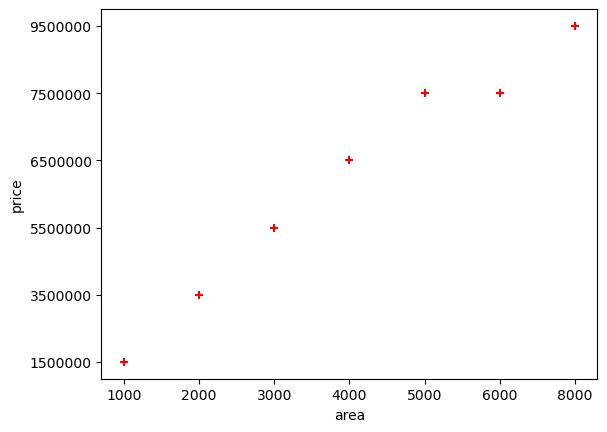

In [17]:
# Plotting the data now 

%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df_cleaned.area,df_cleaned.price,color='red',marker='+')
plt.show()

### 📘 Notes — Prepare Input and Target Variables

This cell separates the dataset into the two parts needed for supervised machine learning.

`df_cleaned.drop('price', axis='columns')`
- Removes the `price` column from the DataFrame.
- `price` is the value we want to predict, so it should not be included in the input features.
- `axis='columns'` tells Pandas that we are removing a column rather than a row.
- The remaining column (`area`) becomes `new_df`, our input feature data.

`price = df_cleaned.price`
- Selects the `price` column as the target/output variable.
- `price` is what the Linear Regression model will learn to predict.

So conceptually:

**Input (X):** area  
**Target (y):** price

This is a standard supervised-learning setup.

In [18]:
# # Create linear regression object
new_df = df_cleaned.drop('price',axis='columns')
price = df_cleaned.price


### 📘 Notes — Create and Train the Linear Regression Model

`reg = linear_model.LinearRegression()`
- Creates a Linear Regression model object.
- At this point, the model has not learned the relationship from our data yet.

`reg.fit(new_df, price)`
- `fit()` is the training step.
- `new_df` contains the input feature(s), such as house area.
- `price` contains the known target values.
- The algorithm finds a mathematical line that best represents the relationship between the input and target in the training data.

Conceptually, Linear Regression learns an equation like:

**price = m × area + b**

where:
- `m` = slope/coefficient learned from the data
- `b` = intercept learned from the data

After `fit()`, the trained model can be used to make predictions for new area values.

In [19]:
reg = linear_model.LinearRegression()
reg.fit(new_df,price)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 📘 Notes — Predict the Price for a New Area

`reg.predict([[230]])` asks the trained model to predict the price for a new input value.

- `predict()` is used after training.
- `[[230]]` represents one observation with one feature.
- The outer list represents the number of samples.
- The inner list represents the feature values for one sample.
- Here, `230` is being supplied as the house area.

The model uses the equation it learned during `fit()` to calculate the predicted price.

**Important:** The prediction input should have the same feature structure used during training.

If the model was trained using a DataFrame with a named column such as `area`, a warning may appear when using `[[230]]` because the prediction data has no feature name. A DataFrame with the same column name avoids that warning:

`reg.predict(pd.DataFrame({'area': [230]}))`

Also remember that predictions are more meaningful when the new input is within a sensible range represented by the training data.

In [20]:
# Predict
reg.predict([[230]])

array([1711024.59016393])